In [38]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

### 1.) Loading the data

In [17]:
# Load the dataset
df = pd.read_csv('EA.csv')

### 2.)Exploratory data analysis

In [18]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [19]:
df.shape

(1470, 35)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [21]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


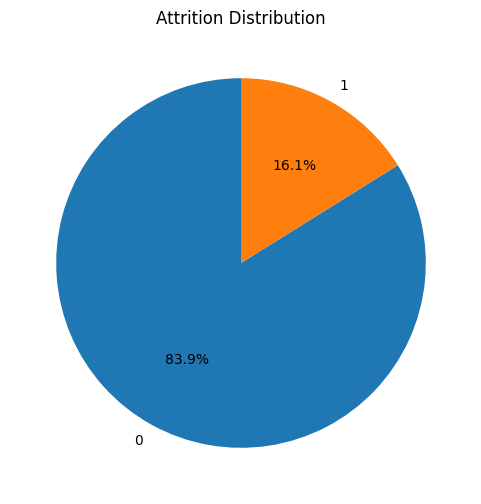

In [ ]:
# Attrition distribution
plt.figure(figsize=(6,6))
df['Attrition'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90)
plt.title('Attrition Distribution')
plt.ylabel('')
plt.show()

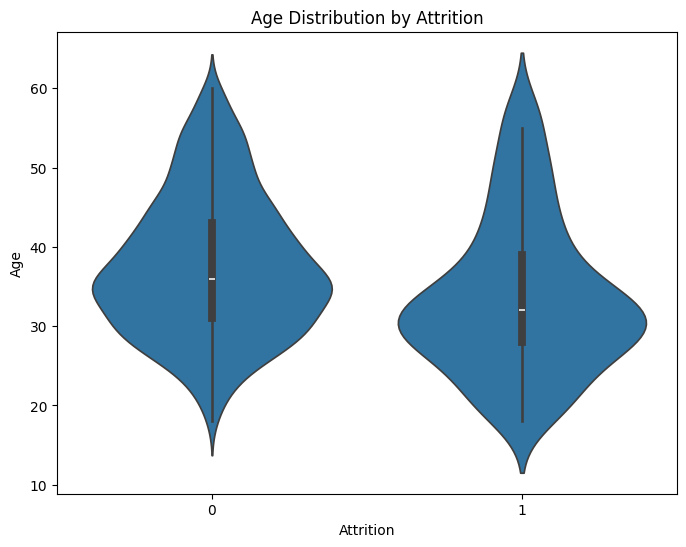

In [43]:
# Age distribution
plt.figure(figsize=(8,6))
sns.violinplot(x="Attrition", y="Age", data=df)
plt.title('Age Distribution by Attrition')
plt.show()

<Figure size 700x500 with 0 Axes>

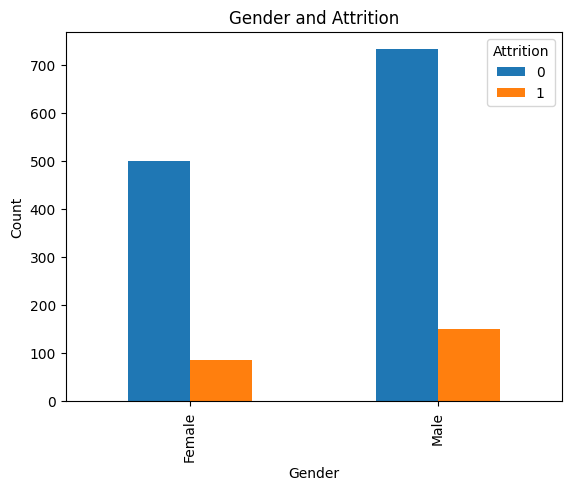

In [42]:
# Gender distribution
plt.figure(figsize=(7,5))
df.groupby(['Gender','Attrition']).size().unstack().plot(kind='bar')
plt.title('Gender and Attrition')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

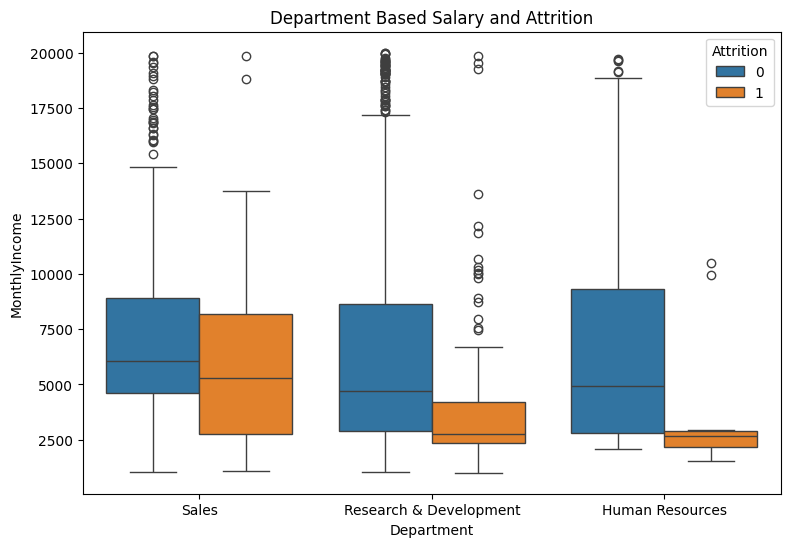

In [45]:
# Department Based Salary and Leave
plt.figure(figsize=(9,6))
sns.boxplot(x="Department", y="MonthlyIncome", hue="Attrition", data=df)
plt.title('Department Based Salary and Attrition')
plt.show()

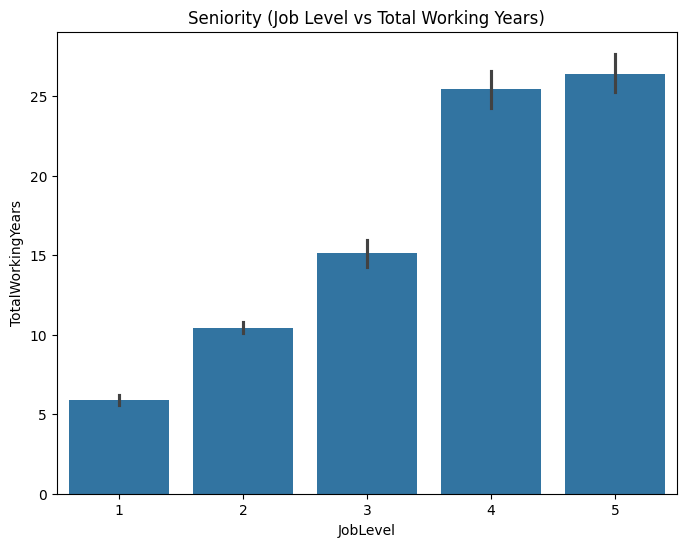

In [48]:
# Seniority 
plt.figure(figsize=(8,6))
sns.barplot(x="JobLevel", y="TotalWorkingYears", data=df)
plt.title('Seniority (Job Level vs Total Working Years)')
plt.show()

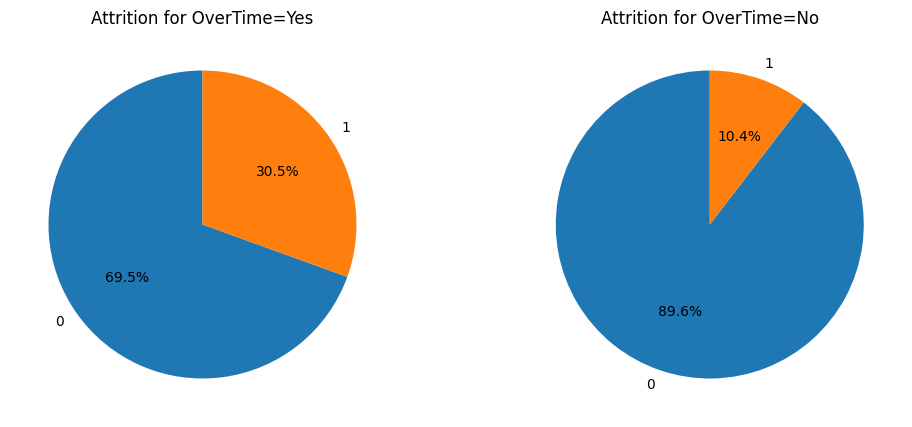

In [50]:
# Overtime and attrition
plt.figure(figsize=(12,5))
for i, status in enumerate(df['OverTime'].unique()):
    plt.subplot(1,2,i+1)
    df[df['OverTime']==status]['Attrition'].value_counts().plot.pie(
        autopct='%1.1f%%',startangle=90)
    plt.title(f'Attrition for OverTime={status}')
    plt.ylabel('')
plt.show()

### 3.) Data preprocessing

In [22]:
# Target variable: convert 'Attrition' to binary (Yes=1, No=0)
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

In [23]:

# Separate features and target
X = df.drop(columns=['Attrition', 'EmployeeCount', 'EmployeeNumber', 
                     'Over18', 'StandardHours'])  
y = df['Attrition']

In [24]:
# Handle categorical variables (One-Hot Encoding)
X = pd.get_dummies(X, drop_first=True)

In [25]:
# Scale numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [26]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

### 4.)Model training


In [28]:
class CustomLogisticRegression:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        """
        Initialize the logistic regression model.

        Args:
            learning_rate (float): Step size for gradient descent updates.
            n_iterations (int): Number of iterations for training.
        """
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.loss_history = []
    
    def sigmoid(self, z):
        """
        Sigmoid activation function.
        Maps input z to a value between 0 and 1.
        """
        return 1 / (1 + np.exp(-z))
    
    def compute_loss(self, y, y_pred):
        """
        Compute binary cross-entropy (log-loss).

        Args:
            y (ndarray): True labels (0 or 1).
            y_pred (ndarray): Predicted probabilities.

        Returns:
            float: Loss value.
        """
        m = len(y)
        return - (1/m) * np.sum(y*np.log(y_pred + 1e-9) + (1-y)*np.log(1-y_pred + 1e-9))
    
    def fit(self, X, y, verbose=False):
        """
        Train the logistic regression model using gradient descent.

        Args:
            X (ndarray): Training features of shape (m, n).
            y (ndarray): Training labels of shape (m,).
            verbose (bool): If True, print loss every 100 iterations.
        """
        m, n = X.shape
        self.weights = np.zeros(n)
        self.bias = 0
        
        for i in range(self.n_iterations):
            # Linear model
            linear_model = np.dot(X, self.weights) + self.bias
            y_pred = self.sigmoid(linear_model)
            
            # Gradients
            dw = (1/m) * np.dot(X.T, (y_pred - y))
            db = (1/m) * np.sum(y_pred - y)
            
            # Update weights and bias
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db
            
            # Track loss
            loss = self.compute_loss(y, y_pred)
            self.loss_history.append(loss)
            
            if verbose and i % 100 == 0:
                print(f"Iteration {i}, Loss: {loss:.4f}")
    
    def predict_proba(self, X):
        """
        Predict probabilities for given input features.

        Args:
            X (ndarray): Input features.

        Returns:
            ndarray: Probabilities between 0 and 1.
        """
        return self.sigmoid(np.dot(X, self.weights) + self.bias)
    
    def predict(self, X, threshold=0.5):
        """
        Predict class labels (0 or 1) based on probability threshold.

        Args:
            X (ndarray): Input features.
            threshold (float): Cut-off for classification.

        Returns:
            ndarray: Predicted labels (0 or 1).
        """
        return np.where(self.predict_proba(X) >= threshold, 1, 0)


### 5.)Model evaluation and Fine-tuning

In [30]:


# Train model with chosen hyperparameters 
model = CustomLogisticRegression(learning_rate=0.1, n_iterations=2000)
model.fit(X_train, y_train.values, verbose=True)



Iteration 0, Loss: 0.6931
Iteration 100, Loss: 0.3396
Iteration 200, Loss: 0.3086
Iteration 300, Loss: 0.2984
Iteration 400, Loss: 0.2937
Iteration 500, Loss: 0.2910
Iteration 600, Loss: 0.2894
Iteration 700, Loss: 0.2883
Iteration 800, Loss: 0.2875
Iteration 900, Loss: 0.2870
Iteration 1000, Loss: 0.2865
Iteration 1100, Loss: 0.2862
Iteration 1200, Loss: 0.2859
Iteration 1300, Loss: 0.2857
Iteration 1400, Loss: 0.2855
Iteration 1500, Loss: 0.2854
Iteration 1600, Loss: 0.2852
Iteration 1700, Loss: 0.2851
Iteration 1800, Loss: 0.2850
Iteration 1900, Loss: 0.2849


In [31]:
# Make predictions 
y_pred = model.predict(X_test, threshold=0.5)




In [32]:
#  Evaluate model 
print("\nModel Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))



Model Evaluation:
Accuracy: 0.8639455782312925
Precision: 0.6296296296296297
Recall: 0.3617021276595745
F1 Score: 0.4594594594594595

Confusion Matrix:
 [[237  10]
 [ 30  17]]


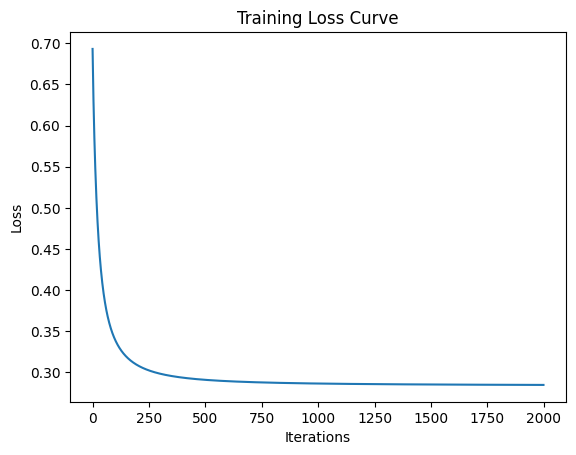

In [33]:

#  Plot loss curve to visualize convergence 
plt.plot(model.loss_history)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()